# 05 — Time-Series Analysis & Prophet Forecast

**Goal:** Analyse how Netflix's library grew over time and forecast future growth.

**Techniques:**
- Content added per year / month
- YoY growth rates
- Seasonal patterns
- Prophet time-series forecast

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook'

from src.data_cleaner import get_clean_df

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

df = get_clean_df()
print(f'Loaded {len(df):,} records')

Loaded 8,807 rows × 12 columns
Dropped 0 duplicate rows
Cleaning complete ✅
type                object
year_added           Int64
duration_numeric     int64
primary_genre       object
Loaded 8,807 records


/Users/vaishnavipujala/Desktop/netflix-eda/src/data_cleaner.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["date_added"].fillna("January 1, 2000", inplace=True)


## 1. Annual Content Added

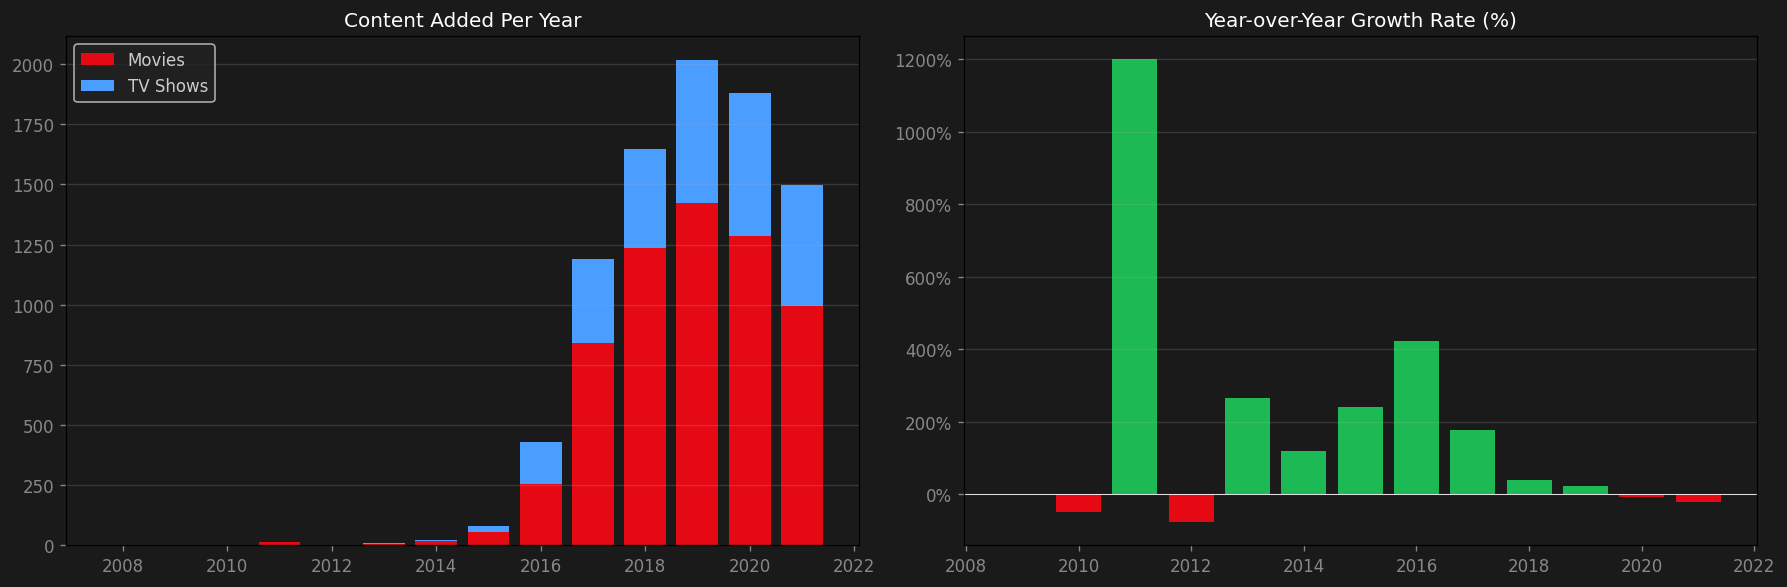


Peak year: 2019 (2,016 titles)
Biggest growth year: 2011 (+1200%)


In [2]:
yearly = (df[df['year_added'].between(2008, 2021)]
          .groupby(['year_added','type'])
          .size().unstack(fill_value=0)
          .reset_index())
yearly.columns = [str(c) for c in yearly.columns]
yearly['year_added'] = yearly['year_added'].astype(int)
yearly['Total'] = yearly.get('Movie', 0) + yearly.get('TV Show', 0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stacked bar
ax = axes[0]
ax.bar(yearly['year_added'], yearly.get('Movie', 0), color='#E50914', label='Movies')
ax.bar(yearly['year_added'], yearly.get('TV Show', 0),
       bottom=yearly.get('Movie', 0), color='#4a9eff', label='TV Shows')
ax.set_title('Content Added Per Year', color='#fff')
ax.legend(facecolor='#222', labelcolor='#ccc')

# YoY growth
ax2 = axes[1]
growth = yearly['Total'].pct_change() * 100
colors = ['#1db954' if v >= 0 else '#E50914' for v in growth]
ax2.bar(yearly['year_added'], growth, color=colors)
ax2.axhline(0, color='#fff', lw=0.5)
ax2.set_title('Year-over-Year Growth Rate (%)', color='#fff')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

for ax in axes:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#888')
    ax.grid(axis='y', alpha=0.2)
fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.show()

print(f"\nPeak year: {yearly.loc[yearly['Total'].idxmax(), 'year_added']} ({yearly['Total'].max():,} titles)")
print(f"Biggest growth year: {yearly.loc[growth.idxmax(), 'year_added']} (+{growth.max():.0f}%)")

## 2. Cumulative Library Size

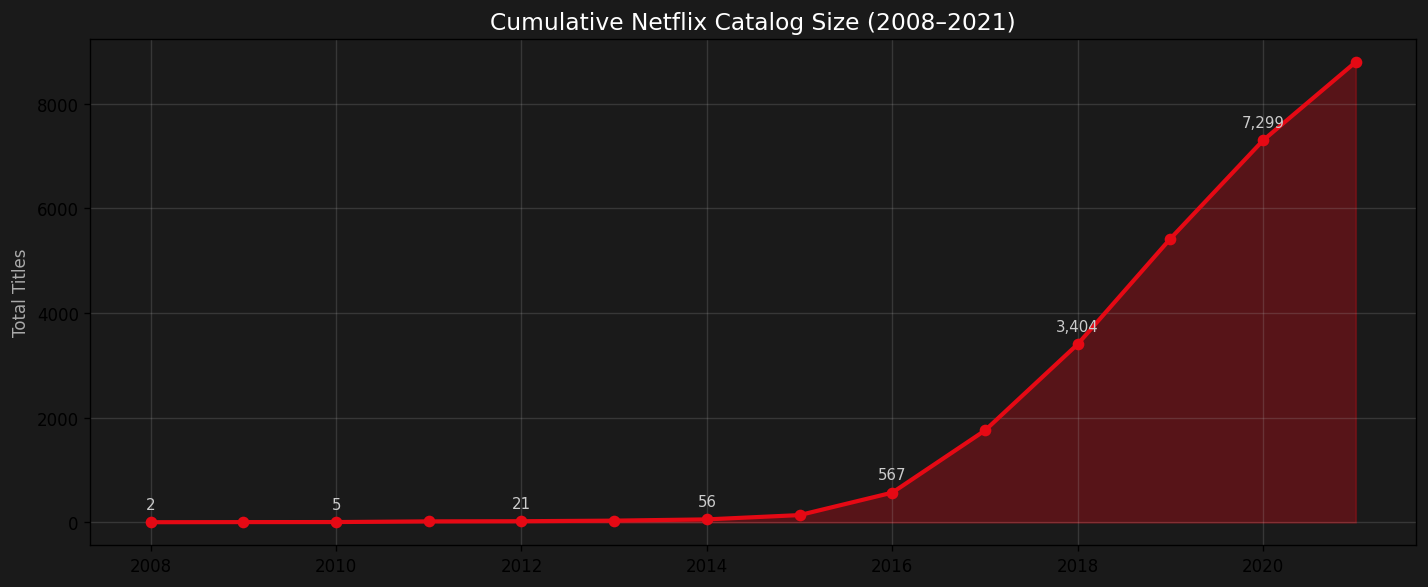

In [3]:
cumulative = df[df['year_added'].between(2008, 2021)].groupby('year_added').size().cumsum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(cumulative.index.astype(int), cumulative.values,
                alpha=0.3, color='#E50914')
ax.plot(cumulative.index.astype(int), cumulative.values, color='#E50914', lw=2.5, marker='o')
for year, val in zip(cumulative.index.astype(int), cumulative.values):
    if year % 2 == 0:
        ax.annotate(f'{val:,}', xy=(year, val), xytext=(0, 8),
                    textcoords='offset points', ha='center', color='#ccc', fontsize=9)
ax.set_title('Cumulative Netflix Catalog Size (2008–2021)', color='#fff', fontsize=14)
ax.set_ylabel('Total Titles', color='#aaa')
ax.set_facecolor('#1a1a1a')
fig.patch.set_facecolor('#1a1a1a')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Prophet Forecast

20:22:18 - cmdstanpy - INFO - Chain [1] start processing
20:22:18 - cmdstanpy - INFO - Chain [1] done processing


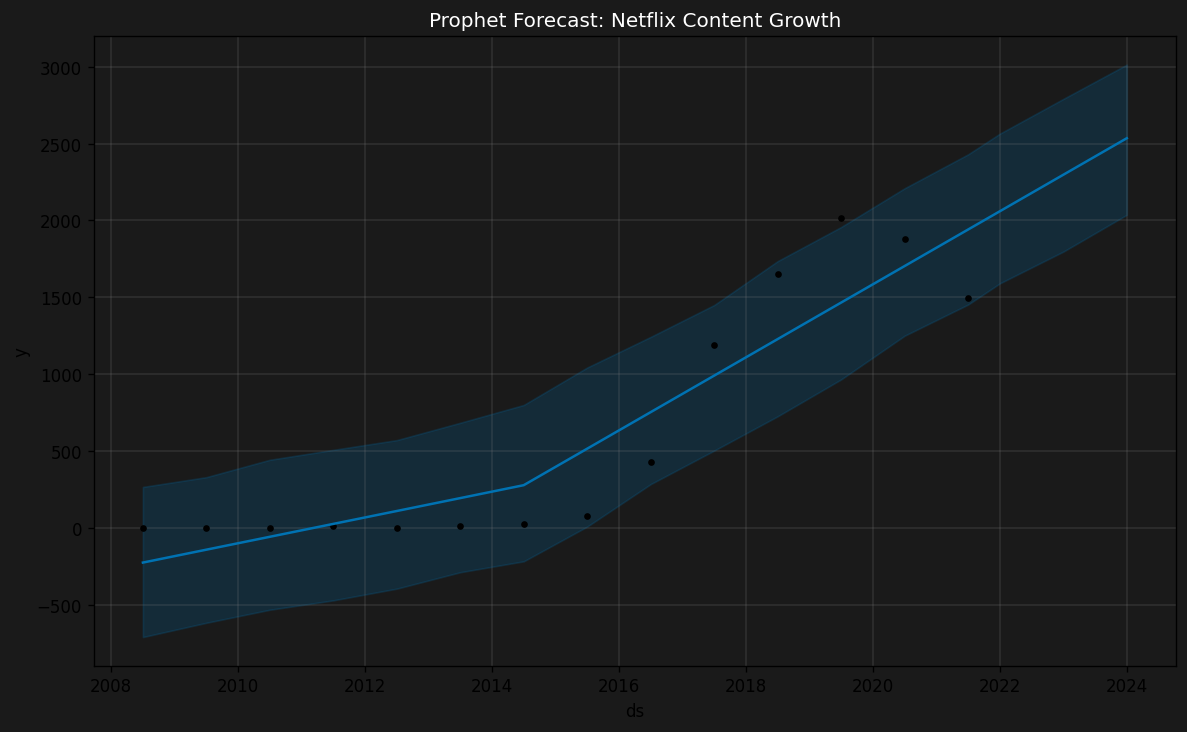


Forecast (2022–2024):
 Year  Predicted  Lower Bound  Upper Bound
 2022       2298         1798         2791
 2023       2535         2037         3013


In [4]:
try:
    from prophet import Prophet

    yearly_total = (df[df['year_added'].between(2008, 2021)]
                    .groupby('year_added').size().reset_index())
    yearly_total.columns = ['ds', 'y']
    yearly_total['ds'] = pd.to_datetime(yearly_total['ds'].astype(str) + '-07-01')

    # Fit Prophet model
    # changepoint_prior_scale: higher = more flexible trend line
    m = Prophet(yearly_seasonality=False, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=0.3,
                interval_width=0.9)
    m.fit(yearly_total)

    # Forecast 3 years ahead
    future = m.make_future_dataframe(periods=3, freq='YE')
    forecast = m.predict(future)

    # Plot with matplotlib
    fig = m.plot(forecast)
    fig.patch.set_facecolor('#1a1a1a')
    fig.axes[0].set_facecolor('#1a1a1a')
    fig.axes[0].set_title('Prophet Forecast: Netflix Content Growth', color='#fff')
    plt.show()

    # Forecast table
    future_years = forecast[forecast['ds'].dt.year > 2021][['ds','yhat','yhat_lower','yhat_upper']]
    future_years['year'] = future_years['ds'].dt.year
    future_years = future_years[['year','yhat','yhat_lower','yhat_upper']].round(0).astype(int)
    future_years.columns = ['Year','Predicted','Lower Bound','Upper Bound']
    print('\nForecast (2022–2024):')
    print(future_years.to_string(index=False))

except ImportError:
    print('Prophet not installed. Run: pip install prophet')
    print('Skipping forecast section.')